# Regresión lineal para predicción de progresión de diabetes
- age: Representa la edad del paciente, normalizada (no es la edad real, sino una representación estandarizada).
- sex: Sexo del paciente, representado como una variable numérica normalizada (valores entre -0.5 y 0.5).
- bmi: Índice de Masa Corporal (Body Mass Index, BMI), una medida del peso relativo al cuadrado de la altura.
- bp:
Promedio de presión arterial (Blood Pressure, BP), normalizada.
- s1: Nivel sérico de lípidos totales (colesterol total).
- s2: Nivel sérico de lipoproteínas de baja densidad (LDL, “colesterol malo”).
- s3: Nivel sérico de lipoproteínas de alta densidad (HDL, “colesterol bueno”).
- s4: Relación entre el colesterol total y HDL.
- s5: Nivel sérico de triglicéridos, representado como una medida numérica normalizada.
- s6: Nivel sérico de glucosa en ayuno, una medida clave en el monitoreo de la diabetes.

In [1]:
# Importar las librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes

# Cargar el conjunto de datos
diabetes_data = load_diabetes()

# Convertir el conjunto de datos a un DataFrame para facilitar su manipulación
df = pd.DataFrame(data=diabetes_data.data, columns=diabetes_data.feature_names)
df['target'] = diabetes_data.target  # Agregar la variable objetivo al DataFrame

# Mostrar las primeras filas del DataFrame
df.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [2]:
# ==========================================
# 1. EXPLORACIÓN DE LOS DATOS
# ==========================================

# Ver información general del DataFrame
print('Forma del dataset:', df.shape)
print()
print(df.info())
print()
print('Estadísticas descriptivas:')
df.describe()

Forma del dataset: (442, 11)

<class 'pandas.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB
None

Estadísticas descriptivas:


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.268604e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [3]:
# Ver cuántos valores nulos hay
print('Valores nulos por columna:')
print(df.isnull().sum())

Valores nulos por columna:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64


In [4]:
# Ver la correlación entre variables y el target
correlaciones = df.corr()['target'].sort_values(ascending=False)
print('Correlación con el target:')
print(correlaciones)

Correlación con el target:
target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


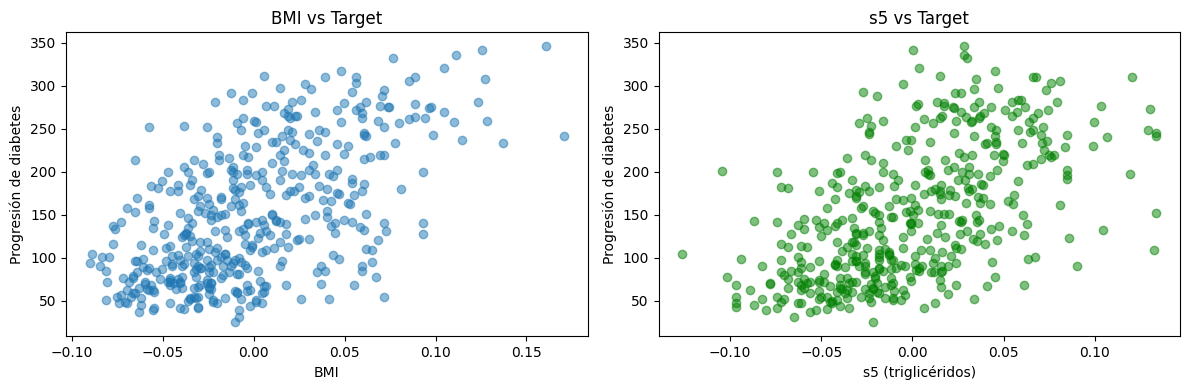

In [5]:
# Gráfica de dispersión: las 2 variables más correlacionadas con el target
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.scatter(df['bmi'], df['target'], alpha=0.5)
plt.xlabel('BMI')
plt.ylabel('Progresión de diabetes')
plt.title('BMI vs Target')

plt.subplot(1, 2, 2)
plt.scatter(df['s5'], df['target'], alpha=0.5, color='green')
plt.xlabel('s5 (triglicéridos)')
plt.ylabel('Progresión de diabetes')
plt.title('s5 vs Target')

plt.tight_layout()
plt.show()

## 2. Preprocesamiento y Entrenamiento del Modelo

In [6]:
# Separar las características (X) y la variable objetivo (y)
X = df.drop('target', axis=1)
y = df['target']

print('X shape:', X.shape)
print('y shape:', y.shape)

X shape: (442, 10)
y shape: (442,)


In [7]:
# Dividir en datos de entrenamiento y prueba (80% train, 20% test)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Train:', X_train.shape)
print('Test:', X_test.shape)

Train: (353, 10)
Test: (89, 10)


In [8]:
# Normalizar las características con StandardScaler
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Media de X_train después de escalar:', X_train_scaled.mean(axis=0).round(4))
print('Std de X_train después de escalar:', X_train_scaled.std(axis=0).round(4))

Media de X_train después de escalar: [-0. -0. -0.  0. -0. -0.  0. -0. -0.  0.]
Std de X_train después de escalar: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [9]:
# Entrenar el modelo de regresión lineal
from sklearn.linear_model import LinearRegression

modelo = LinearRegression()
modelo.fit(X_train_scaled, y_train)

print('Modelo entrenado correctamente')
print('Intercepto:', round(modelo.intercept_, 4))
print('Coeficientes:')
for nombre, coef in zip(X.columns, modelo.coef_):
    print(f'  {nombre}: {round(coef, 4)}')

Modelo entrenado correctamente
Intercepto: 153.7365
Coeficientes:
  age: 1.7538
  sex: -11.5118
  bmi: 25.6071
  bp: 16.8289
  s1: -44.4489
  s2: 24.641
  s3: 7.677
  s4: 13.1388
  s5: 35.1612
  s6: 2.3514


## 3. Evaluación del Modelo

In [10]:
# Hacer predicciones con los datos de prueba
y_pred = modelo.predict(X_test_scaled)

# Mostrar las primeras 10 comparaciones
comparacion = pd.DataFrame({
    'Real': y_test.values[:10],
    'Predicho': y_pred[:10].round(2),
    'Diferencia': (y_test.values[:10] - y_pred[:10]).round(2)
})
print('Comparación Real vs Predicho (primeras 10):')
print(comparacion)

Comparación Real vs Predicho (primeras 10):
    Real  Predicho  Diferencia
0  219.0    139.55       79.45
1   70.0    179.52     -109.52
2  202.0    134.04       67.96
3  230.0    291.42      -61.42
4  111.0    123.79      -12.79
5   84.0     92.17       -8.17
6  242.0    258.23      -16.23
7  272.0    181.34       90.66
8   94.0     90.22        3.78
9   96.0    108.63      -12.63


In [11]:
# Calcular métricas de evaluación: RMSE y R²
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print('=== Métricas del modelo ===')
print(f'MSE:  {round(mse, 4)}')
print(f'RMSE: {round(rmse, 4)}')
print(f'R²:   {round(r2, 4)}')
print()
print('Interpretación:')
print(f'- RMSE: el modelo se equivoca en promedio {round(rmse, 2)} unidades')
print(f'- R²:  el modelo explica el {round(r2 * 100, 2)}% de la variabilidad')

=== Métricas del modelo ===
MSE:  2900.1936
RMSE: 53.8534
R²:   0.4526

Interpretación:
- RMSE: el modelo se equivoca en promedio 53.85 unidades
- R²:  el modelo explica el 45.26% de la variabilidad


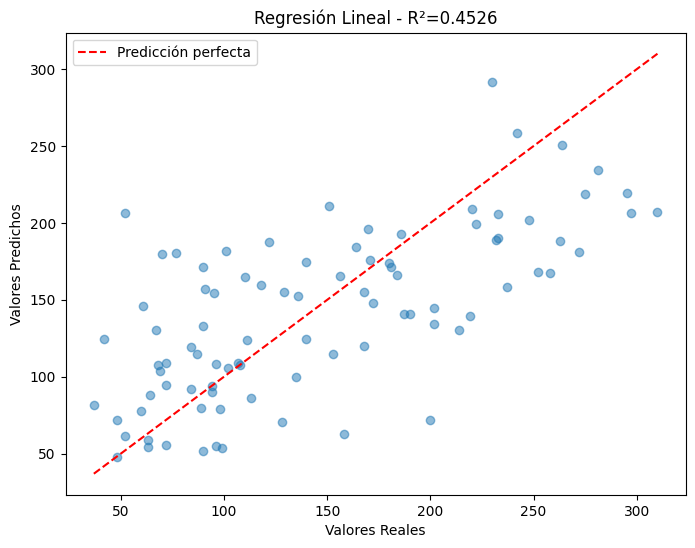

In [12]:
# Gráfica: Valores reales vs predichos
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5)

# Línea perfecta (donde real = predicho)
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Predicción perfecta')

plt.xlabel('Valores Reales')
plt.ylabel('Valores Predichos')
plt.title(f'Regresión Lineal - R²={round(r2, 4)}')
plt.legend()
plt.show()